# (EDA + Data Cleaning)


- imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


- load data

In [27]:
PATH = "../data/raw/clothing_sales.csv"  
df = pd.read_csv(PATH, sep=';', dtype=str) 
print("Loaded:", df.shape)
df.head()


Loaded: (20252, 17)


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product ID        20252 non-null  object
 1   Product Position  20252 non-null  object
 2   Promotion         20252 non-null  object
 3   Product Category  20252 non-null  object
 4   Seasonal          20252 non-null  object
 5   Sales Volume      20252 non-null  object
 6   brand             20252 non-null  object
 7   url               20252 non-null  object
 8   name              20251 non-null  object
 9   description       20250 non-null  object
 10  price             20252 non-null  object
 11  currency          20252 non-null  object
 12  terms             20252 non-null  object
 13  section           20252 non-null  object
 14  season            20252 non-null  object
 15  material          20252 non-null  object
 16  origin            20252 non-null  object
dtypes: object(17

In [25]:
df['brand'].isna().sum()

np.int64(0)

- Shape & Info and some data cleaning

In [4]:
# Normalize column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Convert sales_volume and price to numeric
df['sales_volume'] = pd.to_numeric(df['sales_volume'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Standardize promotion/seasonal to boolean-like integers
df['promotion'] = df['promotion'].str.strip().str.lower().map({'yes':1,'no':0}).fillna(0).astype(int)
df['seasonal'] = df['seasonal'].str.strip().str.lower().map({'yes':1,'no':0}).fillna(0).astype(int)

# Strip leading/trailing whitespace for text columns
text_cols = ['brand','name','description','product_position','product_category','terms','section','season','material','origin']
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().fillna('missing')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        20252 non-null  object 
 1   product_position  20252 non-null  object 
 2   promotion         20252 non-null  int64  
 3   product_category  20252 non-null  object 
 4   seasonal          20252 non-null  int64  
 5   sales_volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20252 non-null  object 
 9   description       20252 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

In [29]:
df['terms'].value_counts()

terms
jackets     11232
sweaters     3257
t-shirts     2646
shoes        2458
jeans         659
Name: count, dtype: int64

- missing values

In [5]:
print("Missing sales_volume:", df['sales_volume'].isnull().sum())
df = df.dropna(subset=['sales_volume']).reset_index(drop=True)
print("Data shape after dropping nulls:", df.shape)

Missing sales_volume: 0
Data shape after dropping nulls: (20252, 17)


- Univariate and Target Distribution

In [6]:
# Univariate analysis (numeric features)
df[['sales_volume','price','promotion','seasonal']].describe()

,sales_volume,price,promotion,seasonal
count,20252.000000,20252.000000,20252.000000,20252.000000
mean,1097.400454,41.949061,0.416749,0.499506
std,298.234609,23.380960,0.493033,0.500012
min,518.000000,12.000000,0.000000,0.000000
25%,849.000000,23.950000,0.000000,0.000000
50%,990.000000,35.950000,0.000000,0.000000
75%,1364.250000,53.950000,1.000000,1.000000
max,1940.000000,134.990000,1.000000,1.000000


In [7]:
df['brand'].value_counts()

brand
Zara    20252
Name: count, dtype: int64

In [8]:
df['currency'].value_counts()

currency
USD    20252
Name: count, dtype: int64

In [9]:

df['name'].value_counts()


name
PLAID OVERSHIRT                                8
POCKET OVERSHIRT                               5
HOODED TECHNICAL JACKET                        5
CONTRASTING PATCHES BOMBER JACKET              5
BOMBER JACKET                                  5
                                              ..
SLIM HEART PRINT T-SHIRT ECRU                  1
REGULAR KNIT PEARL SWEATER BROWN               1
KNIT ABSTRACT PRINT T-SHIRT SAND               1
PAINT PRINT OVERSHIRT OLIVE                    1
UTILITY FAUX LEATHER BOMBER JACKET BURGUNDY    1
Name: count, Length: 17216, dtype: int64

Product Position

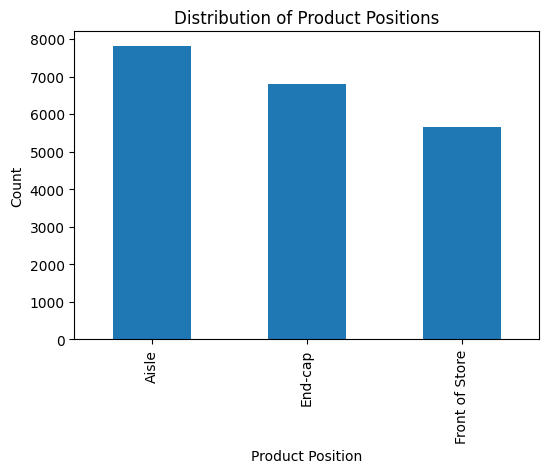

In [10]:
df['product_position'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of Product Positions")
plt.xlabel("Product Position")
plt.ylabel("Count")
plt.show()


Origin

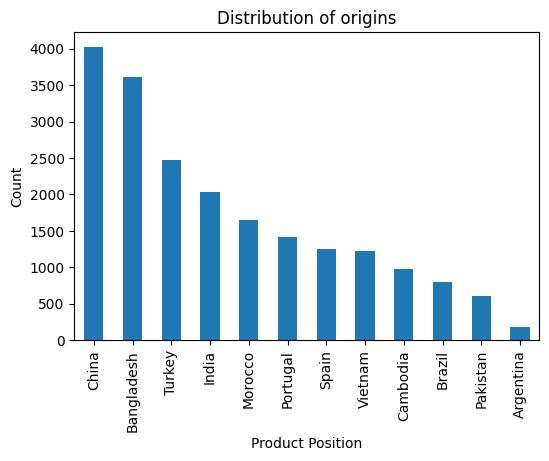

In [19]:
df['origin'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of origins")
plt.xlabel("Product Position")
plt.ylabel("Count")
plt.show()


Seasonal Flag (Yes/No)

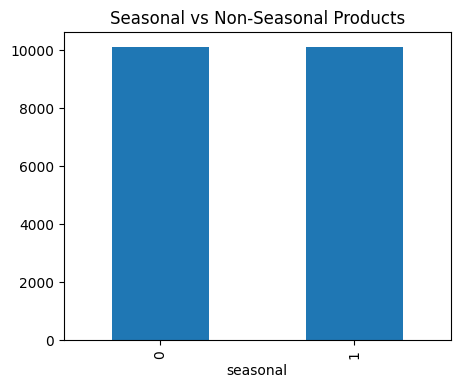

In [12]:
df['seasonal'].value_counts().plot(kind='bar', figsize=(5,4))
plt.title("Seasonal vs Non-Seasonal Products")
plt.show()


Product Category

In [13]:
df['product_category'].value_counts()


product_category
clothing    20252
Name: count, dtype: int64

season

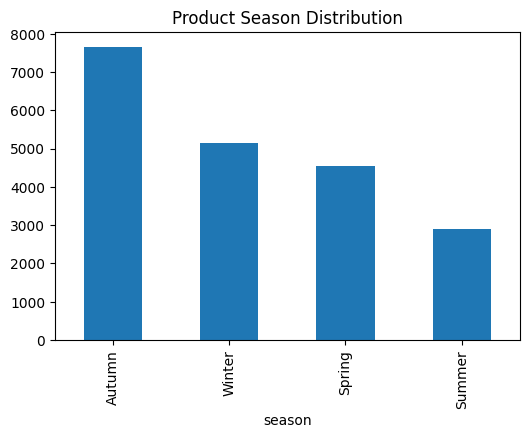

In [14]:
df['season'].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Product Season Distribution")
plt.show()


Material

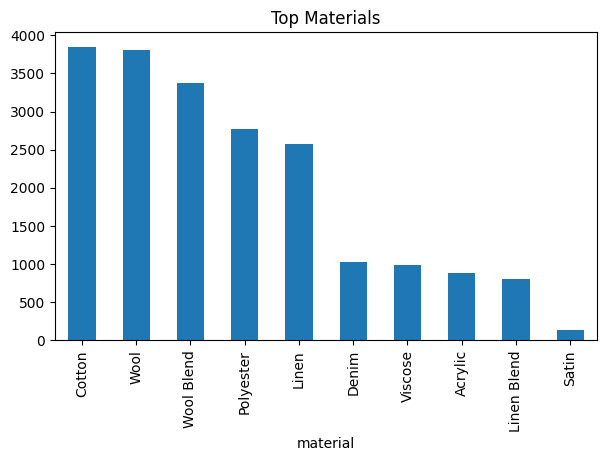

In [15]:
df['material'].value_counts().head(10).plot(kind="bar", figsize=(7,4))
plt.title("Top Materials")
plt.show()


Price distribution

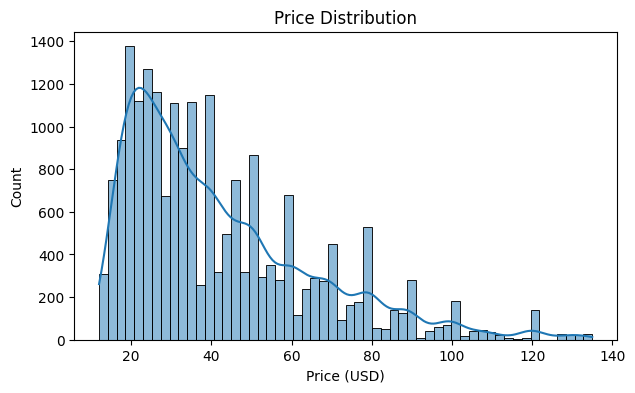

In [16]:
plt.figure(figsize=(7,4))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.show()


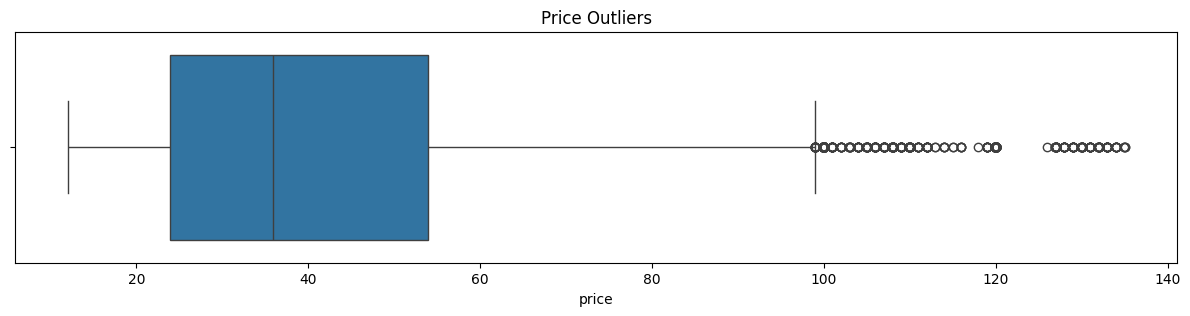

In [17]:
plt.figure(figsize=(15,3))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()


In [18]:
# Target Distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['sales_volume'], bins=40, kde=False)
plt.title('Sales Volume Distribution')

plt.subplot(1,2,2)
sns.boxplot(y=df['sales_volume'])
plt.title('Sales Volume Box Plot (Outlier Detection)')

plt.tight_layout()
plt.show()

# Univariate analysis (categorical features)
print("\nTop product positions:")
print(df['product_position'].value_counts())

print("\nmaterials:")
print(df['material'].value_counts())

print("\nbrands:")
print(df['brand'].value_counts())ori

print("\nNames:")
print(df['name'].value_counts().head(10))

print("\nterms:")
print(df['terms'].value_counts())

SyntaxError: invalid syntax (110831973.py, line 22)

In [ ]:
df.columns

Index(['product_id', 'product_position', 'promotion', 'product_category',
       'seasonal', 'sales_volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

- save clean csv

In [ ]:
# Final Step: Save the cleaned, pre-engineered dataframe for use in Notebook 02.
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/clean_clothing_sales.csv", index=False)
print("Cleaned data saved to ../data/processed/clean_clothing_sales.csv")

Cleaned data saved to ../data/processed/clean_clothing_sales.csv
